In [30]:
# Jupyter notebooks have problems with imports from parent folder, so let's change the path
from jupyter_utils import change_path_to_parent
change_path_to_parent()

import matplotlib
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2
from optmethods.first_order import AdgdAccel
from optmethods.datasets import get_dataset


from optmethods.loss import LogisticRegression, LogSumExp
from optmethods.second_order import Newton
from optmethods.second_order import CaCuAdGD, CaCuAdGDLS
from optmethods.second_order import Cubic, AccCubic, SuperCubic
from optmethods.second_order import CaCuN, AccCaCuN
from optmethods.second_order import Arc, Cubic, Newton, RegNewton
from optmethods.quasi_newton import Bfgs, Dfp, Lbfgs, Sr1, Shorr
from optmethods.first_order import Adgd, AdgdAccel, Gd, Nesterov, Ogm, Polyak, RestNest, NestLine
from optmethods.line_search import Armijo
from optmethods.utils import get_trace, relative_round

sns.set(style="whitegrid", context="talk", palette=sns.color_palette("bright"), color_codes=False)
matplotlib.rc('font', family='sans-serif') 
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['figure.figsize'] = (9, 6)

markers = ['s', 'o', '^', '*', 'v', 'X', '+', 'P', '.', 6, 7]
palette = sns.color_palette("bright")
colors = [0, 1, 2, 4, 3, 5, 6, 7, 8, 9, 0]

def plot_h_hat_markers(opt, color_idx=None, s=100, linewidths=1, alpha=1, label='CaCuAdGD: cubic step'):
    h_hat_its = getattr(opt.trace, 'h_hat_used_its', [])
    h_hat_loss_vals = getattr(opt.trace, 'h_hat_used_loss_vals', [])
    if not h_hat_its or not h_hat_loss_vals:
        return
    f_opt = opt.trace.loss.f_opt
    pairs = [(it, loss_val - f_opt) for it, loss_val in zip(h_hat_its, h_hat_loss_vals)]
    pairs = [(x, y) for x, y in pairs if y > 0]
    if not pairs:
        return
    xs, ys = zip(*pairs)
    color = 'black' if color_idx is None else palette[color_idx]
    marker = matplotlib.markers.MarkerStyle(matplotlib.markers.TICKRIGHT)
    marker._transform = marker.get_transform().rotate_deg(45)
    plt.scatter(xs, ys, color=color, marker=marker, s=s, linewidths=linewidths, alpha=alpha, label=label, zorder=5)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
l2 = 1e-7
# l2 = 0.
ifl2 = f"_l2_{l2}" if l2 > 0 else ""

In [32]:
dataset = 'covtype'
A, b = get_dataset(dataset)

b = np.asarray(b).ravel()
u = np.unique(b)
if u.size == 2 and set(u) <= {0,1}:
    b = b.astype(np.float64)
else:
 b = (b == 1).astype(np.float64)

n, dim = A.shape
A = A.astype(np.float64, copy=False)

loss = LogisticRegression(A, b, l1=0, l2=l2)

x0 = np.zeros(dim)
# loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
# loss.f_opt = 0.4657138629352897 #l2 = 0
# loss.f_opt = 0.46580040590571636 #l2 = 1e-7

Running optimizer: AdGD


CPU times: user 2min 43s, sys: 81.9 ms, total: 2min 43s
Wall time: 1min 23s
Running optimizer: NesterovLS
CPU times: user 12min 49s, sys: 106 ms, total: 12min 49s
Wall time: 6min 32s
Running optimizer: Polyak
CPU times: user 3min 48s, sys: 62.1 ms, total: 3min 48s
Wall time: 1min 56s
Running optimizer: Steepest Descent
CPU times: user 52min 2s, sys: 1.08 s, total: 52min 3s
Wall time: 26min 31s
Running optimizer: CaCuAdGD
CPU times: user 6min 38s, sys: 112 ms, total: 6min 39s
Wall time: 3min 23s


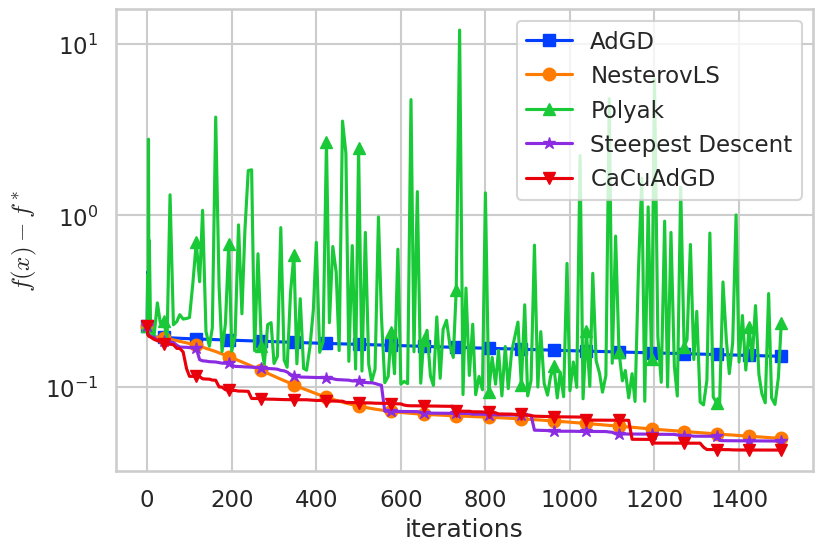

In [33]:
if l2 == 0.:
    loss.f_opt = 0.4657138629352897
elif l2 == 1e-7:
    loss.f_opt = 0.46580040590571636
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
    
adgd = Adgd(loss=loss, label='AdGD')
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
nest = NestLine(loss=loss, label='NesterovLS')
cacuadgdls = CaCuAdGDLS(loss=loss, label='Steepest Descent')

optimizers = [adgd, nest, pol, cacuadgdls, cacuadgd]

it_max = 1500
time=False
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker, color_idx in zip(optimizers, markers, colors):
    opt.trace.plot_losses(marker=marker, color=palette[color_idx])
plt.yscale('log')
plot_h_hat_markers(cacuadgd, color_idx=colors[optimizers.index(cacuadgd)])
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

Running optimizer: AdGD


CPU times: user 3min 16s, sys: 62.9 ms, total: 3min 16s
Wall time: 1min 40s
Running optimizer: NesterovLS
CPU times: user 3min 15s, sys: 29.8 ms, total: 3min 15s
Wall time: 1min 40s
Running optimizer: Polyak
CPU times: user 3min 15s, sys: 117 ms, total: 3min 15s
Wall time: 1min 40s
Running optimizer: Steepest Descent
CPU times: user 3min 17s, sys: 49.6 ms, total: 3min 17s
Wall time: 1min 40s
Running optimizer: CaCuAdGD
CPU times: user 3min 16s, sys: 70.8 ms, total: 3min 16s
Wall time: 1min 40s


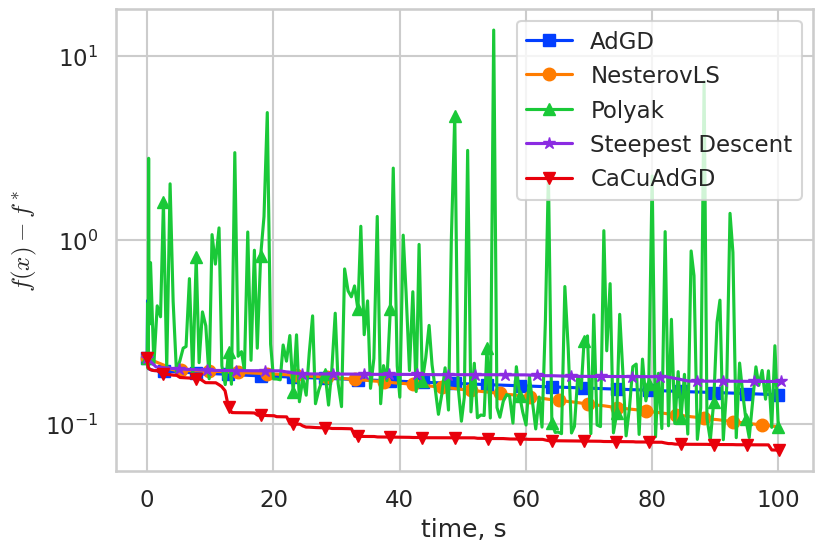

In [34]:
if l2 == 0.:
    loss.f_opt = 0.4657138629352897
elif l2 == 1e-7:
    loss.f_opt = 0.46580040590571636
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
adgd = Adgd(loss=loss, label='AdGD')
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
nest = NestLine(loss=loss, label='NesterovLS')
cacuadgdls = CaCuAdGDLS(loss=loss, label='Steepest Descent')

optimizers = [adgd, nest, pol, cacuadgdls, cacuadgd]

time=True
t_max = 100
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker, color_idx in zip(optimizers, markers, colors):
    opt.trace.plot_losses(marker=marker, color=palette[color_idx], time=time, use_ls_its=False)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

In [35]:
dataset = 'w8a'
A, b = get_dataset(dataset)

n, dim = A.shape
# A = A.astype(np.float64, copy=False)

loss = LogisticRegression(A, b, l1=0, l2=l2)

x0 = np.zeros(dim)

The passed labels have values in the set {-1, 1}. Changing them to {0, 1}


fopt=np.float64(0.11114926683217005)
Running optimizer: AdGD
CPU times: user 1.1 s, sys: 241 μs, total: 1.1 s
Wall time: 1.1 s
Running optimizer: NesterovLS
CPU times: user 4.62 s, sys: 710 μs, total: 4.62 s
Wall time: 4.62 s
Running optimizer: Polyak
CPU times: user 1.92 s, sys: 186 μs, total: 1.92 s
Wall time: 1.92 s
Running optimizer: Steepest Descent
CPU times: user 31.4 s, sys: 4.02 ms, total: 31.4 s
Wall time: 31.4 s
Running optimizer: CaCuAdGD
CPU times: user 3.63 s, sys: 508 μs, total: 3.63 s
Wall time: 3.63 s


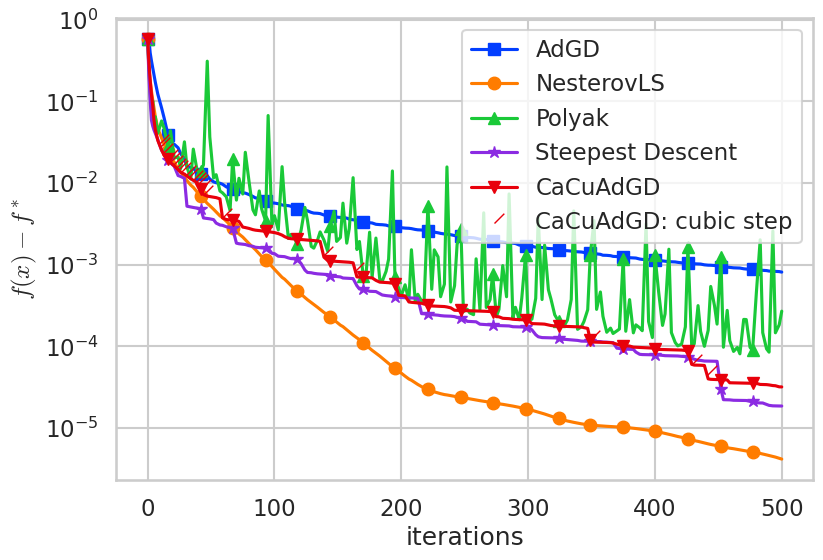

In [36]:
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
adgd = Adgd(loss=loss, label='AdGD')
nest = NestLine(loss=loss, label='NesterovLS')
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
cacuadgdls = CaCuAdGDLS(loss=loss, label='Steepest Descent')

optimizers = [adgd, nest, pol, cacuadgdls, cacuadgd]

time=False
it_max = 500
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker, color_idx in zip(optimizers, markers, colors):
    opt.trace.plot_losses(marker=marker, color=palette[color_idx])
plt.yscale('log')
plot_h_hat_markers(cacuadgd, color_idx=colors[optimizers.index(cacuadgd)])
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

fopt=np.float64(0.11114926683217005)
Running optimizer: AdGD
CPU times: user 20 s, sys: 2.49 ms, total: 20 s
Wall time: 20 s
Running optimizer: NesterovLS
CPU times: user 19.9 s, sys: 2.3 ms, total: 19.9 s
Wall time: 20 s
Running optimizer: Polyak
CPU times: user 20 s, sys: 2.04 ms, total: 20 s
Wall time: 20 s
Running optimizer: Steepest Descent
CPU times: user 20 s, sys: 12.4 ms, total: 20 s
Wall time: 20 s
Running optimizer: CaCuAdGD
CPU times: user 19.9 s, sys: 2.33 ms, total: 19.9 s
Wall time: 20 s


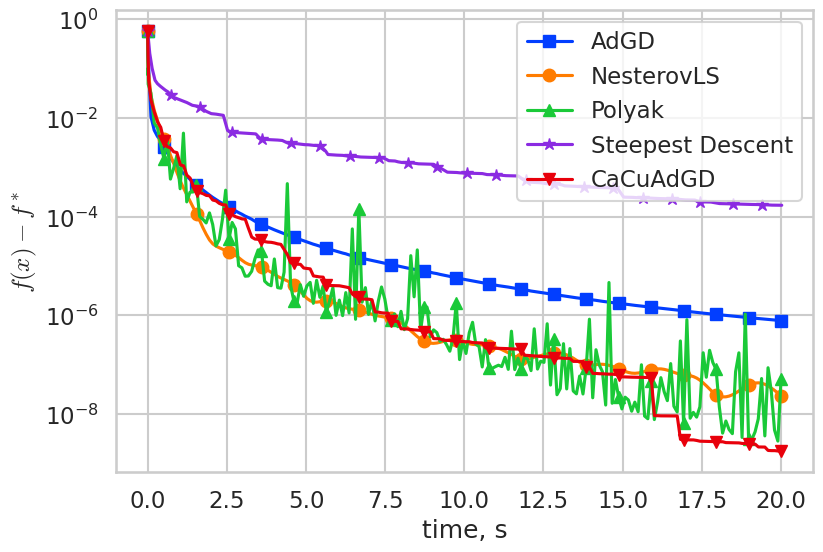

In [37]:
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
adgd = Adgd(loss=loss, label='AdGD')
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
nest = NestLine(loss=loss, label='NesterovLS')
cacuadgdls = CaCuAdGDLS(loss=loss, label='Steepest Descent')

optimizers = [adgd, nest, pol, cacuadgdls, cacuadgd]

time=True
t_max = 20
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker, color_idx in zip(optimizers, markers, colors):
    opt.trace.plot_losses(marker=marker, color=palette[color_idx], time=time)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

In [38]:
dataset = 'mushrooms'
A, b = get_dataset(dataset)

n, dim = A.shape
A = A.astype(np.float64, copy=False)

loss = LogisticRegression(A, b, l1=0, l2=l2)

x0 = np.zeros(dim)
# loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
# fopt=np.float64(0.1108110124131768)

The passed labels have values in the set {1, 2}. Changing them to {0, 1}


fopt=np.float64(6.931666498087653e-05)
Running optimizer: AdGD
CPU times: user 217 ms, sys: 193 μs, total: 217 ms
Wall time: 217 ms
Running optimizer: NesterovLS


CPU times: user 976 ms, sys: 145 μs, total: 976 ms
Wall time: 976 ms
Running optimizer: Polyak
CPU times: user 354 ms, sys: 0 ns, total: 354 ms
Wall time: 354 ms
Running optimizer: Steepest Descent
CPU times: user 3.89 s, sys: 494 μs, total: 3.89 s
Wall time: 3.89 s
Running optimizer: CaCuAdGD
CPU times: user 685 ms, sys: 172 μs, total: 686 ms
Wall time: 686 ms


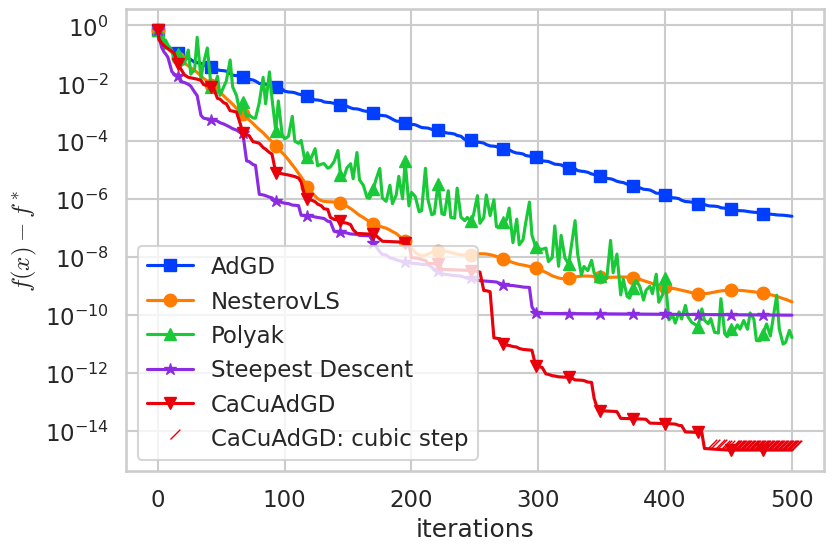

In [39]:
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
adgd = Adgd(loss=loss, label='AdGD')
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
nest = NestLine(loss=loss, label='NesterovLS')
cacuadgdls = CaCuAdGDLS(loss=loss, label='Steepest Descent')

optimizers = [adgd, nest, pol, cacuadgdls, cacuadgd]

time=False
it_max = 500
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker, color_idx in zip(optimizers, markers, colors):
    opt.trace.plot_losses(marker=marker, color=palette[color_idx])
plt.yscale('log')
plot_h_hat_markers(cacuadgd, color_idx=colors[optimizers.index(cacuadgd)])
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

fopt=np.float64(6.931666498087653e-05)
Running optimizer: AdGD
CPU times: user 2 s, sys: 219 μs, total: 2 s
Wall time: 2 s
Running optimizer: NesterovLS


CPU times: user 2 s, sys: 300 μs, total: 2 s
Wall time: 2 s
Running optimizer: Polyak
CPU times: user 1.97 s, sys: 245 μs, total: 1.97 s
Wall time: 2 s
Running optimizer: Steepest Descent
CPU times: user 2 s, sys: 156 μs, total: 2 s
Wall time: 2 s
Running optimizer: CaCuAdGD
CPU times: user 2 s, sys: 290 μs, total: 2 s
Wall time: 2 s


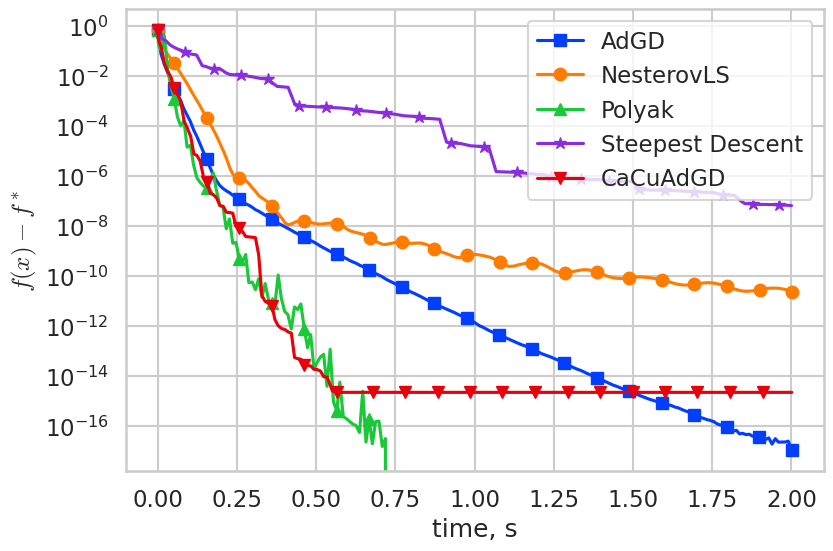

In [40]:
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
adgd = Adgd(loss=loss, label='AdGD')
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
nest = NestLine(loss=loss, label='NesterovLS')
cacuadgdls = CaCuAdGDLS(loss=loss, label='Steepest Descent')

optimizers = [adgd, nest, pol, cacuadgdls, cacuadgd]

time=True
t_max = 2
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker, color_idx in zip(optimizers, markers, colors):
    opt.trace.plot_losses(marker=marker, color=palette[color_idx], time=time)
plt.yscale('log')
plt.legend()
plt.savefig(f'logistic_{dataset}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

## LogSumExp

In [44]:
n, dim = 2000, 1400
n, dim = 500, 200
least_squares_term = False
max_smoothing = 0.05
loss = LogSumExp(n=n, dim=dim, least_squares_term=least_squares_term, l2=l2, max_smoothing=max_smoothing)
# x0 = rng.normal(scale=0.5, size=dim)
x0 = np.ones(dim)
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)

fopt=np.float64(3.5676479024770744)


Running optimizer: AdGD
CPU times: user 486 ms, sys: 29.7 ms, total: 516 ms
Wall time: 500 ms
Running optimizer: NesterovLS
CPU times: user 1.84 s, sys: 50.1 ms, total: 1.89 s
Wall time: 1.84 s
Running optimizer: Polyak
CPU times: user 1.22 s, sys: 123 μs, total: 1.22 s
Wall time: 1.21 s
Running optimizer: Steepest Descent


CPU times: user 17.4 s, sys: 166 ms, total: 17.6 s
Wall time: 17.3 s
Running optimizer: CaCuAdGD
CPU times: user 2.08 s, sys: 40.7 ms, total: 2.12 s
Wall time: 2.05 s


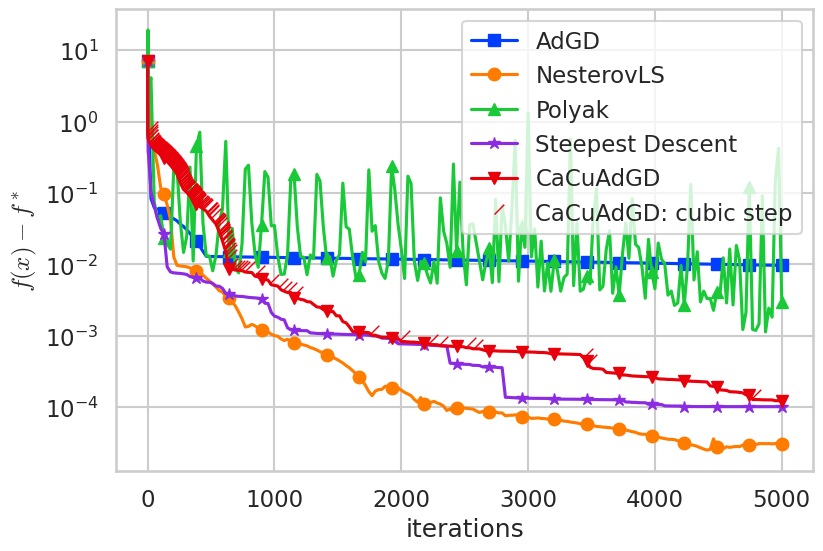

In [45]:
adgd = Adgd(loss=loss, label='AdGD')
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
nest = NestLine(loss=loss, label='NesterovLS')
cacuadgdls = CaCuAdGDLS(loss=loss, label='Steepest Descent')

optimizers = [adgd, nest, pol, cacuadgdls, cacuadgd]

time=False
it_max = 5000
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, it_max=it_max)
    opt.compute_loss_of_iterates()

for opt, marker, color_idx in zip(optimizers, markers, colors):
    opt.trace.plot_losses(marker=marker, color=palette[color_idx])
plt.yscale('log')
plot_h_hat_markers(cacuadgd, color_idx=colors[optimizers.index(cacuadgd)])
plt.legend()
plt.savefig(f'logsumexp_{n,dim,max_smoothing}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')

fopt=np.float64(3.5676479024770744)
Running optimizer: AdGD
CPU times: user 3.11 s, sys: 425 μs, total: 3.11 s
Wall time: 3 s
Running optimizer: NesterovLS
CPU times: user 3.01 s, sys: 31 ms, total: 3.04 s
Wall time: 3 s
Running optimizer: Polyak


CPU times: user 2.99 s, sys: 70 ms, total: 3.06 s
Wall time: 3 s
Running optimizer: Steepest Descent
CPU times: user 3.08 s, sys: 121 ms, total: 3.2 s
Wall time: 3 s
Running optimizer: CaCuAdGD
CPU times: user 3.05 s, sys: 51.2 ms, total: 3.1 s
Wall time: 3 s


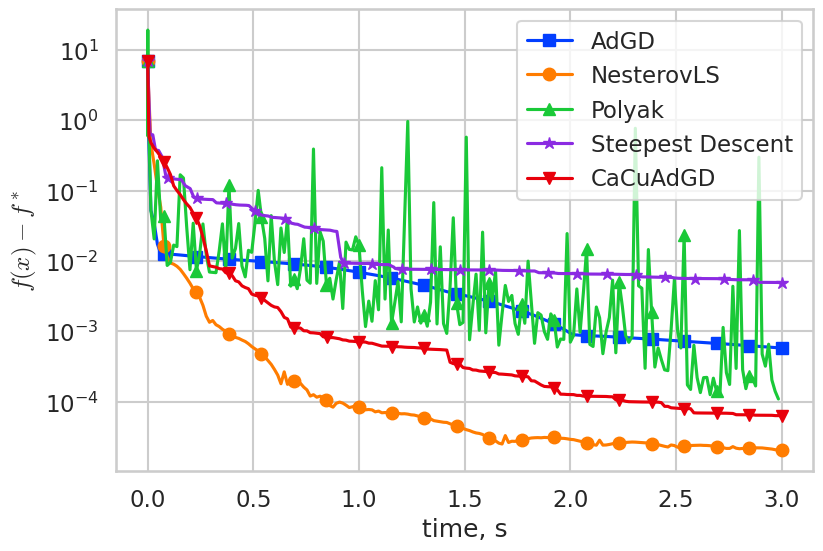

In [46]:
loss.f_opt = SuperCubic(loss=loss, label='super').run(x0, it_max=40000)
adgd = Adgd(loss=loss, label='AdGD')
pol = Polyak(loss=loss, label='Polyak', f_opt=loss.f_opt)
cacuadgd = CaCuAdGD(loss=loss, label='CaCuAdGD')
nest = NestLine(loss=loss, label='NesterovLS')
cacuadgdls = CaCuAdGDLS(loss=loss, label='Steepest Descent')

optimizers = [adgd, nest, pol, cacuadgdls, cacuadgd]

time=True
t_max = 3
for opt in optimizers:
    print(f'Running optimizer: {opt.label}')
    %time opt.run(x0=x0, t_max=t_max)
    opt.compute_loss_of_iterates()

for opt, marker, color_idx in zip(optimizers, markers, colors):
    opt.trace.plot_losses(marker=marker, color=palette[color_idx], time=time)
plt.yscale('log')
plt.legend()
plt.savefig(f'logsumexp_{n,dim,max_smoothing}_cacuadgd_{"t" if time == True else "i"}'+ifl2 + '.pdf', bbox_inches='tight')